In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw2-task2.ipynb")

# Homework 2 - Task 2: Classification 
## Predicting High Asthma Prevalence : Do Social and Economic Conditions Predict Whether a Community Has Elevated Asthma Risk?

---

### Background

The **CDC/ATSDR Environmental Justice Index (EJI)** measures the cumulative environmental and social burdens faced by communities across the United States at the census-tract level. It combines three modules:

- **Environmental Burden Module (EBM)**: air quality, proximity to hazardous waste sites, impaired water bodies
- **Social Vulnerability Module (SVM)**: poverty, unemployment, race/ethnicity, housing conditions, health insurance
- **Health Vulnerability Module (HVM)**: prevalence of asthma, cancer, diabetes, mental illness

Research consistently shows that communities with greater poverty, unemployment, and minority populations bear a disproportionate share of environmental health burdens — including elevated rates of asthma. But can we actually predict which census tracts are in the top tier of asthma prevalence using only social vulnerability indicators?

**Your goal** is to build and compare two binary classification models — **K-Nearest Neighbors (KNN)** and **Logistic Regression** — that predict whether a census tract falls in the **top third** of asthma prevalence nationally. You will use **5-fold cross-validation** to select the best KNN hyperparameter and compare the results of both models. 

---

### Download the data
Follow these instructions to obtain the data for this assignment: 
1. Navigate to [this link](https://www.atsdr.cdc.gov/place-health/php/eji/eji-data-download.html)
1. Select the 2024 dropdown for the United States. 
2. **Choose the CSV File Type, and then click "Go"**. 
3. Add your data to the `task2/` folder. Your fle path should look like this for the autograder to run: `task2/EJI_2024_United_States.csv`. 
3. Don't forget to add your data to your `gitignore`! 


### Dataset 
Each row is a **U.S. census tract**. The variables used in this assignment are:

#### Response Variable

| Column | Description |
|---|---|
| `F_ASTHMA` | **Binary flag** — equals `1` if the tract's asthma prevalence percentile rank (`EPL_ASTHMA`) is above the 66th percentile, `0` otherwise |

#### Predictor Variables

| Column | Description | 
|---|---|
| `EPL_POV200` | Percentile rank for the share of residents below 200% of the federal poverty level | 
| `EPL_UNEMP` | Percentile rank for the civilian unemployment rate |
| `EPL_MINRTY` | Percentile rank for the share of residents identifying as a racial or ethnic minority | 

All three predictors are **percentile ranks** (0 = lowest burden, 1 = highest burden), so they are already on a comparable scale — no standardization is required.

### Setup: Load libraries and read in data

Run the cell below. It loads the EJI data, replaces the EPA missing-value (`-999`) with `NaN`, and takes a reproducible random sample of **10,000 tracts** so that cross-validated KNN runs in a reasonable time.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_curve, auc
)

# Load and clean
df_raw = pd.read_csv('EJI_2024_United_States.csv')
df_raw = df_raw.replace(-999, np.nan)

# Reproducible 10,000-tract sample
df = df_raw.sample(n=10_000, random_state=42).reset_index(drop=True)
df.head(3)

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,72,21,31023,140000US72021031023,72021031023,72021031023,Bayamón Municipio,Puerto Rico,PR,Census Tract 310.23; Bayamón Municipio; Puerto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-999,NaN
1,51,810,46400,140000US51810046400,51810046400,51810046400,Virginia Beach city,Virginia,VA,Census Tract 464; Virginia Beach city; Virginia,...,0.2,0.0,0.0,125.0,2.2,0.0,0.0,0.000000,-999,NaN
2,30,47,940600,140000US30047940600,30047940600,30047940600,Lake County,Montana,MT,Census Tract 9406; Lake County; Montana,...,26.6,6.0,0.1,420.0,8.6,3.0,0.1,99.994102,Flathead Reservation,1.0


<!-- BEGIN QUESTION -->

---
## Step 1: Explore Class Balance / Imbalance in Response Variable

Before building any model, we need to understand the distribution of our response variable `F_ASTHMA`. This is a binary flag that equals **1** if a census tract's asthma prevalence percentile rank is above the 66th percentile and **0** otherwise.

An imbalanced dataset — where one class appears far more often than the other — can mislead accuracy-based metrics and cause models to favor the majority class. Visualizing class counts first helps us anticipate this.

Create a bar chart of our binary response variable, `F_ASTHMA`. Be sure to include a title, x and y axis labels, and update from the default color. 

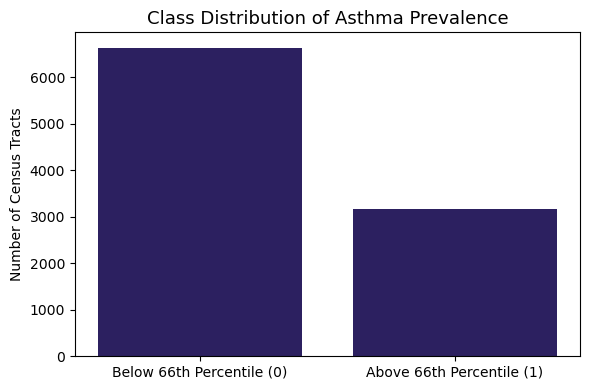


Class counts:
 F_ASTHMA
Below 66th Percentile    6634
Above 66th Percentile    3171
Name: count, dtype: int64


In [4]:
# Response variable: Count tracts per class and sort the classes
counts = df['F_ASTHMA'].value_counts().sort_index()

# Create plot labels
labels = ['Below 66th Percentile (0)', 'Above 66th Percentile (1)']

# Create empty figure
fig, ax = plt.subplots(figsize=(6,4))

# Incorporate axes and axes labels
ax.bar(labels, counts.values, color = '#2c2060')
ax.set_ylabel('Number of Census Tracts')
plt.title('Class Distribution of Asthma Prevalence', fontsize = 13)
plt.tight_layout()
plt.show()
print('\nClass counts:\n', counts.rename({0: 'Below 66th Percentile', 
                                          1: 'Above 66th Percentile'}))


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

> **Q1:** Describe the class balance / imbalance. If there is an imbalance, how might it affect our classification algorithm? 

From the bar chart, there is a clear class imbalance; census tracts below the 66th percentile are roughly twice as numerous as those above it. This imbalance can bias the classification model toward predicting the majority class, since it has more training examples to learn from. As a result, the model may achieve high overall accuracy while performing poorly on the minority class. This imbalance reduces the model's ability to correctly identify tracts above the 66th percentile.


<!-- END QUESTION -->

---
## Step 2: Prepare Features for Modeling

Complete the following steps:

1. Create a dataframe called `df_model` that contains the following predictor variables: `EPL_POV200`, `EPL_UNEMP`, and `EPL_MINRTY`, and your response variable: `F_ASTHMA`.
2. Drop any rows in `df_model` with NAs. `KNeighborsClassifier` doesn't allow any NAs.
3. Create a variable `X` containing your predictors, and `y` containing your response variable.
4. Split into 70% train / 30% test using `train_test_split` with `stratify=y` and `random_state=42`. Store as `X_train`, `X_test`, `y_train`, `y_test`.

Because all three predictors are already percentile ranks on a 0–1 scale, features won't dominate KNN distances due to differing units, so no standardization step is needed.

In [5]:
# List the variables of interest
var_of_interest = ['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY', 'F_ASTHMA']

# Create dataframe containing variables of interest, including response
df_model = df[var_of_interest].dropna()

# Separate predictors from response
X = df_model[['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY']].values
y = df_model['F_ASTHMA'].astype('int')

# Extract training set 70/30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=42)

# Diplay the number of tracts on the training and test set
print(f'Training set : {X_train.shape[0]:,} tracts')
print(f'Test set     : {X_test.shape[0]:,} tracts')

Training set : 6,813 tracts
Test set     : 2,920 tracts


In [6]:
grader.check("q3")

q3 results: All test cases passed!

---
## Step 3: Fit a K-Nearest Neighbors Classifier (k = 3)

As a starting point, fit a `KNeighborsClassifier` with `n_neighbors=3` on the training data. Store the fitted model in `knn3`, predictions on the test set in `y_pred_knn3`, and test-set accuracy in `knn3_accuracy`.

**sklearn workflow reminder:**
```python
model = SomeClassifier(...)        # 1. initialize
model.fit(X_train, y_train)        # 2. fit on training data
y_pred = model.predict(X_test)     # 3. predict on test data
acc = accuracy_score(y_test, y_pred)  # 4. evaluate
```
We'll use k = 3 here as a baseline, then use cross-validation in Step 4 to find the optimal k.

In [7]:
# Fit KNN with k = 3
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)

# Estimate Y from test set
y_pred_knn3   = knn3.predict(X_test)

# Calculate the accuracy score
knn3_accuracy = accuracy_score(y_test, y_pred_knn3)

# Print the result
print(f'KNN (K=3) test accuracy: {knn3_accuracy:.4f}')

KNN (K=3) test accuracy: 0.7418


In [8]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 4: Selecting K with 5-Fold Cross-Validation

Choosing K by checking accuracy on a single test split is risky because the result depends on which observations land in the test set. **Cross-validation** gives a more reliable estimate by rotating through multiple train splits on the training data, leaving the test set untouched.

Using `cross_val_score` with `cv=5`, compute the **mean** and **standard deviation** of the 5-fold cross-validation overall accuracy on the **training set** for each K from 1 to 20. Then:

1. Store the mean CV scores in `cv_mean_scores`. (a numpy array of length 20).
2. Plot mean CV accuracy.
3. Store the K with the **highest mean CV score** in `optimal_k` (smallest K in case of a tie) and that score in `best_cv_score`.

Once we have found the best value of K to use, we will run another KNN Model with the test data that hasn't been used to fit any model yet. 

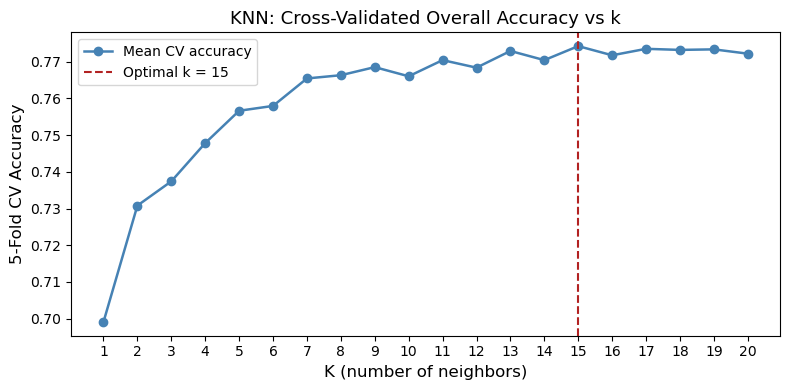

Optimal K = 15,  best mean CV accuracy = 0.7743


In [15]:
# k-fold cross validation with 
k_values      = list(range(1,21))

# Create empty lists to store the mean and standard deviation scores
cv_mean_scores = [] 
cv_std_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(knn, X_train, y_train, cv = 5,
                             scoring = 'accuracy')
    
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())

# Convert to array for easier functionality 
cv_mean_scores = np.array(cv_mean_scores)
cv_std_scores = np.array(cv_std_scores)

# Find the most optimal k-value from tuning
optimal_k     = k_values[np.argmax(cv_mean_scores)]

# Find the best cv score
best_cv_score = cv_mean_scores.max()

# Visualize optimal k
fig, ax = plt.subplots(figsize=(8, 4))  
ax.plot(k_values, cv_mean_scores, marker='o', color='steelblue', linewidth=1.8, label='Mean CV accuracy')  
ax.axvline(optimal_k, color='firebrick', linestyle='--', label=f'Optimal k = {optimal_k}')  
ax.set_xlabel('K (number of neighbors)', fontsize=12)  
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)  
ax.set_title('KNN: Cross-Validated Overall Accuracy vs k', fontsize=13) 
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))  
ax.legend()  
plt.tight_layout()  
plt.show()  

print(f'Optimal K = {optimal_k},  best mean CV accuracy = {best_cv_score:.4f}')

In [16]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2:** Why is using cross-validation to select K better than using the single test-set accuracy from Step 3? What would you e

Cross-validation is better for selecting K because it evaluates each K value across multiple training/validation splits within the training data instead of relying on a single test split. A single test-set accuracy can depend heavily on which observations happened to be placed in the test set, which may give an unreliable estimate of the overall model performance. Thereifore, using the 5-fold cross-validation gives a more reliable average accuracy for each K while still keeping the test set untouched for the final model evaluation.

<!-- END QUESTION -->

---
## Step 5: KNN with Optimal K
 Re- run your  K-Nearest Neighbors Classifier with number of neighbors equal to  `optimal_k`. Store your accuracy in `knn_optimal_accuracy`.



In [ ]:
# Fit KNN with optimal k = 15
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

# Estimate Y from test set
y_pred_knn_best  = knn_optimal.predict(X_test)

# Calculate the accuracy score from the optimal K
knn_optimal_accuracy = accuracy_score(y_test, y_pred_knn_best)

# Display the resulting k and corresponding accuracy
print(f'KNN (K={optimal_k}) test accuracy: {knn_optimal_accuracy:.4f}')

KNN (K=15) test accuracy: 0.7760


In [20]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->


> **Q3:** Compare the test-set accuracy of `knn3` (K = 3) and `knn_optimal` (K = `optimal_k`). Which performed better, and by how much? Why might the optimal K found by cross-validation outperform the arbitrary choice of K = 3?

The test-set accuracy for `knn3` was approximately 0.74, while the test-set accuracy for `knn_optimal` with K = 15 was about 0.78. Therefore, the KNN model with K = 15 performed better by about 0.04, or 4 percentage points. The optimal K found by cross-validation outperformed the arbitrary choice of K = 3 because cross-validation evaluated each K across multiple splits of the training data and selected the value with the best average performance. In contrast, choosing K = 3 is arbitrary and may not provide the best balance between flexibility and generalization. A larger K, like 15, can also reduce sensitivity to individual noisy observations compared with a K of 3.

<!-- END QUESTION -->

---
## Step 6: Logistic Regression with Cross-Validation


We will now create a Logistic Regression with the same predictors and outcome variable. 

1. Create a [`LogisticRegressionCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html) with `random_state=42` and `cv = 5`. Call it `lr`. The CV at the end of Logistic Regression is for cross fold validation. This allows you to use cross fold validation in your regression. 

>  Unlike plain [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression), LogisticRegressionCV automatically selects the best regularization strength C using 5-fold cross-validation. Regularization penalizes large coefficients to reduce overfitting; C controls how strong that penalty is. The cross-validation tries a range of C values and picks the one with the best average held-out accuracy across the 5 folds. 

2. Fit `lr` on the full training set, predict on the test set, and store predictions in `y_pred_lr` and test-set accuracy in `lr_accuracy`. This will be using the default threshold of $\alpha=0.5$.
3. Extract the coefficients from your linear regression with `.coef_[]` and `.intercept_[]`. Create a table with a feature and coefficient column to present your results. 

In [ ]:
# Create a LogisticRegressionCV
lr = LogisticRegressionCV(random_state = 42, cv = 5)

# Fit the logistic regression on the full training set
lr.fit(X_train, y_train)

# Predict on the test set
y_pred_lr   = lr.predict(X_test)

# Find the test-set accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

0.7753424657534247

In [ ]:
# Extract coefficients
lr_coef = lr.coef_[0]
lr_intercept = lr.intercept_[0]

# Feature names
feature_names = ["EPL_POV200", "EPL_UNEMP", "EPL_MINRTY"]

# Create a table with feature and coefficient columns
lr_table = pd.DataFrame({
    "Feature": ["Intercept"] + feature_names,
    "Coefficient": [lr_intercept] + list(lr_coef)
})

# Display the table
lr_table

,Feature,Coefficient
0,Intercept,-3.320082
1,EPL_POV200,5.008554
2,EPL_UNEMP,0.891915
3,EPL_MINRTY,-1.379598


In [56]:
grader.check("q9")

q9 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Which predictors have a negative association with a tract being flagged for high asthma prevalence? Interpret one of them in plain 
  language,
>
> **Note:** Notice this is an inference question. In this case we are using only a subset of the training data to answer it for convenience, but the best practice is to use *all the available data* to investigate inference questions and use a *training/test data* splot for prediction.

The predictor with a negative association is `EPL_MINRTY`, with a coefficient of -1.379598. This means that, in this model, higher values of `EPL_MINRTY` are linked to a lower predicted chance of being classified as high asthma prevalence, after accounting for poverty and unemployment.

<!-- END QUESTION -->

---
## Step 7: Confusion Matrix for Logistic Regression

Compute the **confusion matrix** for the logistic regression predictions on the test set. Store the 2 x 2 numpy array in `cm_lr`. Plot it using `ConfusionMatrixDisplay` with display labels `['0', '1]'`.

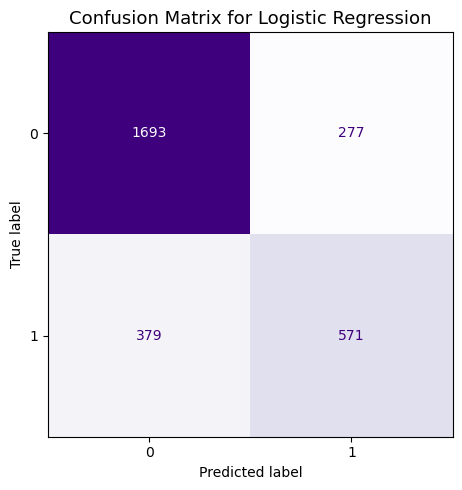

In [67]:
# Compute the confusion matrix for the logistic regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Store the confusion matrix as disp
disp = ConfusionMatrixDisplay(confusion_matrix = cm_lr, 
                              display_labels = ['0', '1'])


# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax = ax, 
          colorbar = False, 
          cmap = 'Purples')

# Display the plot
ax.set_ylim(len(['0', '1']) - 0.5, -0.5)
ax.set_title('Confusion Matrix for Logistic Regression', fontsize = 13)
plt.tight_layout()
plt.show()


In [68]:
grader.check("q11")

q11 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

Class **1** indicates that a census tract was flagged for high asthma prevalence, while class **0** indicates that a census tract was not flagged. There were **1,693 true negatives**, **277 false positives**, **379 false negatives**, and **571 true positives**. The true negatives represent census tracts that were correctly predicted as not flagged for high asthma prevalence. The false positives represent 277 census tracts that the model predicted as flagged, even though they were actually not flagged. Conversely, the 379 false negatives represent census tracts that the model predicted as not flagged, even though they actually were flagged for high asthma prevalence. Lastly, the 571 true positives represent census tracts that were correctly predicted as flagged for high asthma prevalence.

Overall, the model correctly identified many non-flagged tracts and some flagged high-asthma tracts, but it also missed 379 tracts that were actually high-asthma. In this context, false negatives may be especially important because they represent communities that the model failed to identify as having high asthma prevalence.


<!-- END QUESTION -->

---
## Step 8: Accuracy Metrics for Logistic Regression

 Calculate accuracy, precision, recall, and the F1 score. Store your results in `accuracy_lr`, `precision_lr`, `recall_lr`, and `f1_lr` with the functions from `sklearn.metrics`.

In [72]:
# Calculate the accuracy, precision, recall, and F1 scores
accuracy_lr  = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr    = recall_score(y_test, y_pred_lr)
f1_lr        = f1_score(y_test, y_pred_lr)

# Print the results
print(f'Accuracy  = {accuracy_lr:.4f}')
print(f'Precision = {precision_lr:.4f}')
print(f'Recall    = {recall_lr:.4f}')
print(f'F1 Score  = {f1_lr:.4f}')

Accuracy  = 0.7753
Precision = 0.6733
Recall    = 0.6011
F1 Score  = 0.6352


In [71]:
grader.check("q13")

q13 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Compare the accuracy, precision, recall, and F1 score for the logistic regression model. In the context of predicting high asthma risk tracts, which metric do you think is most important, and why? What is the trade-off between precision and recall here?

In the context of predicting high asthma risk tracts, I think recall is the most important metric. Recall measures how well the model identifies the tracts that truly are flagged for high asthma prevalence. This matters because a false negative means the model fails to identify a tract that may need attention or resources. In this context, missing high-risk communities could be more harmful than incorrectly flagging some lower-risk tracts.

The trade-off is that increasing recall can lower precision. In other words, the model may correctly catch more truly high-asthma tracts, but it may also produce more false positives by flagging some tracts that are not actually high-risk. Higher precision would mean that the tracts predicted as high-risk are more likely to truly be high-risk, but it could come at the cost of missing more actual high-risk tracts. Because this task is related to public health risk, I would prioritize recall over precision, while still monitoring precision so the model does not over-flag too many tracts.  

<!-- END QUESTION -->

---
## Step 9: Confusion Matrix and Accuracy Metrics for KNN

Compute and plot the confusion matrix  for the **KNN (K = `optimal_k`)** model. Then calculate precision, recall, and F1 score. This lets you directly compare it to logistic regression beyond just overall accuracy.

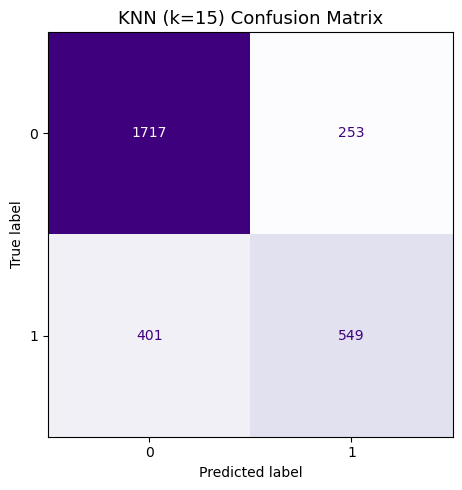

KNN (k=15) Confusion Matrix:
[[1717  253]
 [ 401  549]]

Precision (KNN): 0.6845
Recall    (KNN): 0.5779
F1 Score  (KNN): 0.6267

--- Model Comparison ---
              KNN (k=15)    Logistic Reg
Accuracy:     0.7760         0.7753
F1 Score:     0.6267         0.6352


In [73]:
# Compute the confusion matrix for the KNN (k = 15) model
cm_knn = confusion_matrix(y_test, y_pred_knn_best)

# Save confusion matrix as disp
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels = ['0', '1'])

# Plot the confusion matrix for the KNN model with optimal k
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax = ax, colorbar=False, cmap='Purples')

# Display Plot
ax.set_ylim(len(['0', '1']) - 0.5, -0.5)
ax.set_title('KNN (k=15) Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Calculate precision, recall, and F1 scores
precision_knn = precision_score(y_test, y_pred_knn_best)
recall_knn    = recall_score(y_test, y_pred_knn_best)
f1_knn        = f1_score(y_test, y_pred_knn_best)

# Print the results
print(f'KNN (k={optimal_k}) Confusion Matrix:\n{cm_knn}\n')
print(f'Precision (KNN): {precision_knn:.4f}')
print(f'Recall    (KNN): {recall_knn:.4f}')
print(f'F1 Score  (KNN): {f1_knn:.4f}')
print()
print('--- Model Comparison ---')
print(f'              KNN (k={optimal_k})    Logistic Reg')
print(f'Accuracy:     {knn_optimal_accuracy:.4f}         {lr_accuracy:.4f}')
print(f'F1 Score:     {f1_knn:.4f}         {f1_lr:.4f}')

In [74]:
grader.check("q15")

q15 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Comment on the results of the Logistic Regression vs KNN. How do they compare in terms of performance? Which model would you pick? Why? 

The KNN model with K = 15 and the Logistic Regression model performed very similarly overall. KNN had a slightly higher accuracy (0.7760) compared with Logistic Regression (0.7753), but the difference is extremely small. Logistic Regression had a higher F1 score (0.6352) than KNN (0.6267), suggesting that it had a slightly better balance between precision and recall.

I would choose the Logistic Regression model because, in the context of identifying high asthma risk tracts, recall is especially important. Logistic Regression had a recall of about 0.60, compared with about 0.58 for KNN, meaning it identified a slightly larger share of the truly high-risk tracts. Even though the difference is small, Logistic Regression also has the advantage of being more interpretable because its coefficients show the direction of association between each predictor and the outcome.

<!-- END QUESTION -->

---
## Step 10: ROC Curve and AUC — Logistic Regression

The **Receiver Operating Characteristic (ROC)** curve plots the **True Positive Rate (Recall)** against the **False Positive Rate** across every possible classification threshold — not just the default 0.5 cutoff. This lets us see how the model trades off between catching more high-risk tracts (higher recall) and generating more false alarms (higher FPR).


Follow these steps:

1. **Get predicted probabilities.** Use `lr.predict_proba(X_test)` to get the predicted probability for each test observation. This returns a 2-column array — column 0 is the probability of class 0 (low asthma risk), column 1 is the probability of class 1 (high asthma risk). Keep only the class 1 probabilities and store in `y_proba_lr`.

2. **Compute the ROC curve.** Call `roc_curve(y_test, y_proba_lr)`. It returns three arrays: `fpr` (false positive rates), `tpr` (true positive rates), and `thresholds` — one entry per decision threshold the model evaluated.

3. **Compute AUC.** Pass `fpr` and `tpr` to `auc()` and store the result in `roc_auc`.

4. **Plot the ROC curve.** Create a line plot with `fpr` on the x-axis and `tpr` on the y-axis. Add a dashed diagonal line from (0, 0) to (1, 1) to represent a random classifier. Include axis labels, a title, and a legend that displays the AUC value.

In [82]:
# Obtain the predicted probabilities
y_proba_lr = lr.predict_proba(X_test)[:,1]

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

# Compute AUC
roc_auc = auc(fpr, tpr)
roc_auc

0.8244178466470745

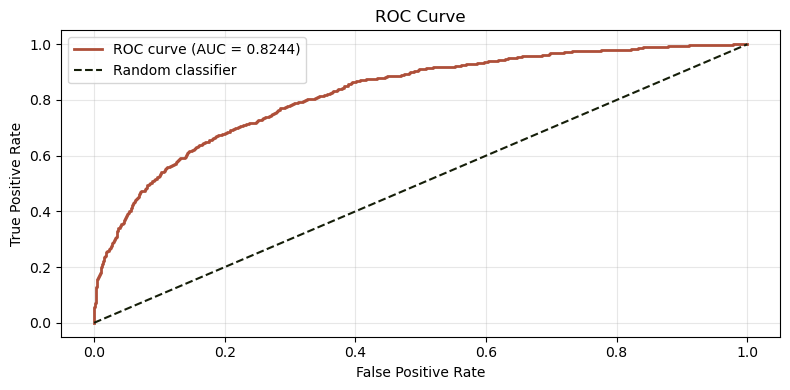

Logistic Regression AUC: 0.8244


In [86]:
# Obtain the predicted probabilities
y_proba_lr = lr.predict_proba(X_test)[:,1]

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
fig, ax = plt.subplots(figsize=(8, 4))

# Add ROC curve and random classifier lines
ax.plot(fpr, tpr, color = '#ae4f39', linewidth = 2, 
         label=f"ROC curve (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle="--", 
        label="Random classifier",
        color = '#151e09')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Logistic Regression AUC: {roc_auc:.4f}')

In [87]:
grader.check("q17")

q17 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q7:** What does the AUC score tell you about the logistic regression model's ability to distinguish between high and low asthma risk tracts? Is this model meaningfully better than random guessing? How does the shape of the ROC curve reflect the precision-recall trade-off you observed in Step 8?

The AUC score of 0.8244 indicates that the logistic regression model has a good ability to distinguish between tracts flagged for high asthma prevalence and tracts that are not flagged. Since an AUC of 0.50 would represent random guessing, this model is meaningfully better than random guessing. The shape of the ROC curve also supports this interpretation because the curve stays well above the diagonal random-classifier line. This means the model can achieve relatively high true positive rates while keeping false positive rates lower than random guessing would. 

In regards to the precision-recall trade-off from Step 8, the curve shows that changing the classification threshold could increase recall by identifying more high-risk tracts, but this would likely come with more false positives. That trade-off is important in this context because improving recall may help catch more high asthma risk tracts, but it may also reduce precision by flagging more tracts that are not actually high-risk.

<!-- END QUESTION -->



---

**Run the cell below to receive credit for autograded questions**

In [88]:
grader.check_all()

q11 results: All test cases passed!

q13 results: All test cases passed!

q15 results: All test cases passed!

q17 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!